LightGBM vs XGBoost on Diabetes Dataset

Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [2]:
!pip install lightgbm xgboost

Load Dataset

In [3]:
df = pd.read_csv("/content/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Exploratory Data Analysis (EDA)

Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Shape

In [5]:
print(df.shape)

(768, 9)


Statistical Summary

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Missing Values

In [7]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

(df[cols]==0).sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


Histograms

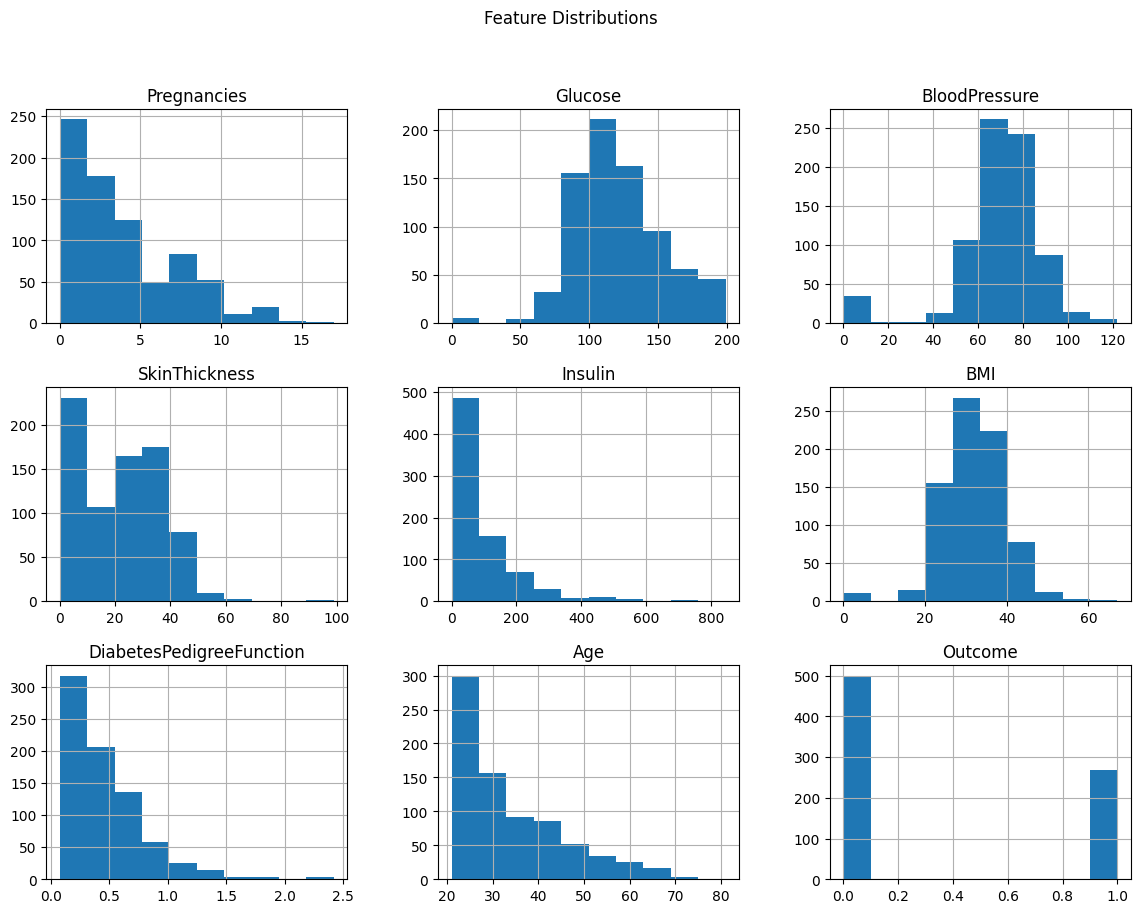

In [9]:
df.hist(figsize=(14,10))
plt.suptitle("Feature Distributions")
plt.show()

Boxplots

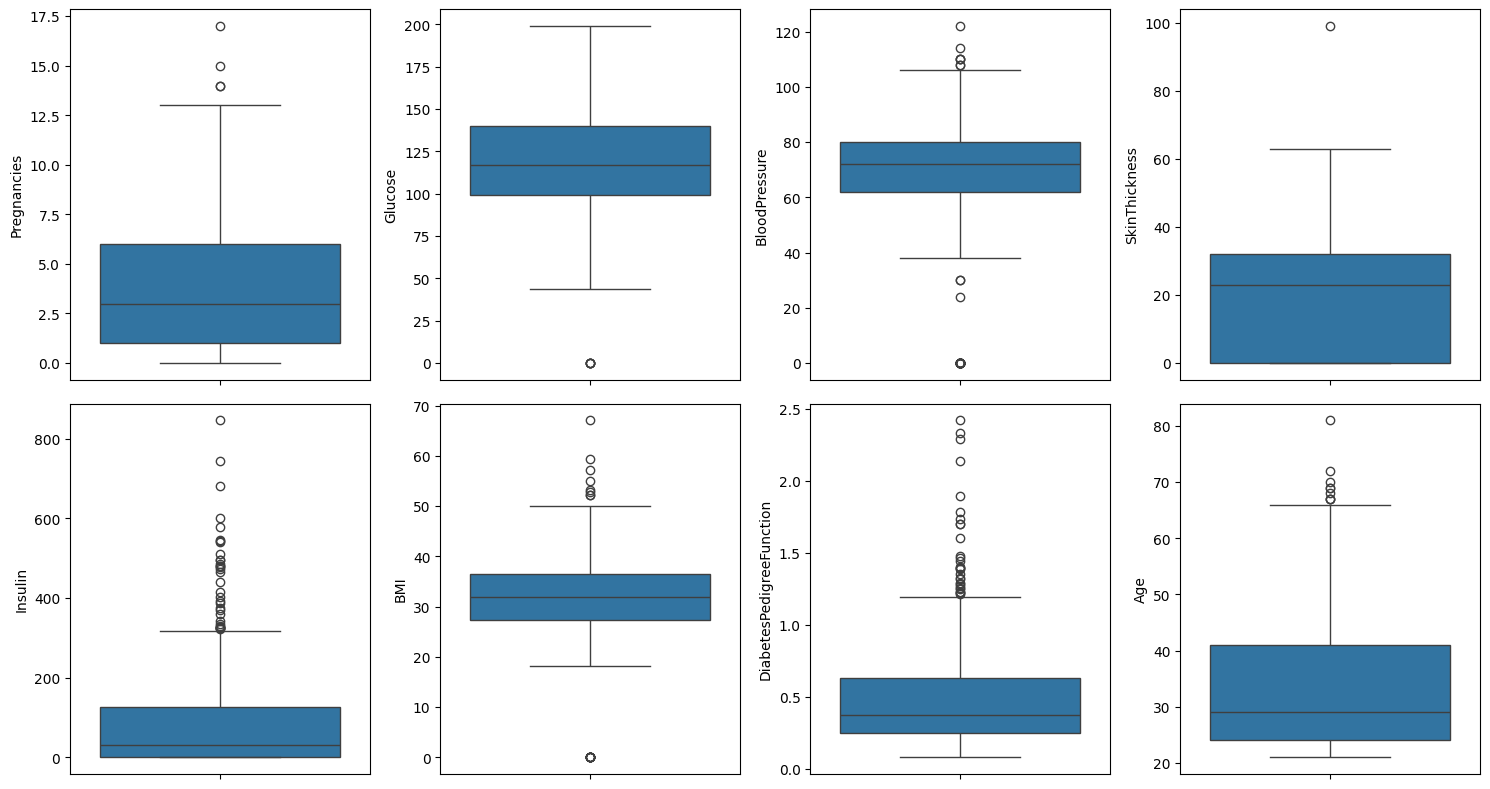

In [10]:
plt.figure(figsize=(15,8))

for i,col in enumerate(df.columns[:-1]):
    plt.subplot(2,4,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

Correlation Heatmap

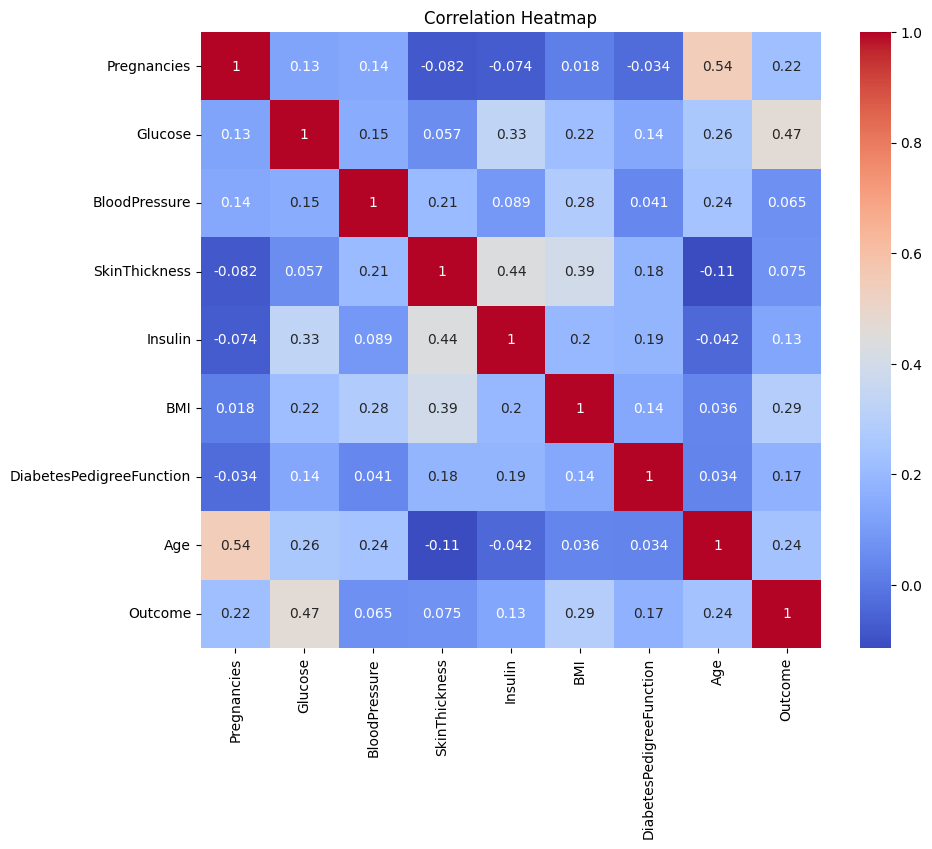

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

Outcome Distribution

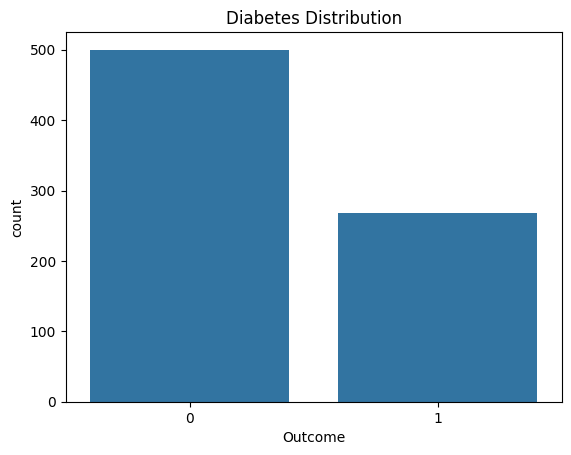

In [12]:
sns.countplot(x='Outcome',data=df)

plt.title("Diabetes Distribution")
plt.show()

Scatter Plot

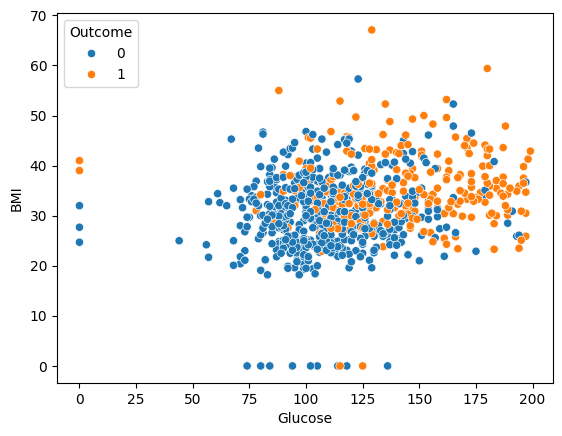

In [13]:
sns.scatterplot(x='Glucose',
                y='BMI',
                hue='Outcome',
                data=df)

plt.show()

Data Preprocessing

Replace invalid zero values.

In [14]:
cols=['Glucose',
      'BloodPressure',
      'SkinThickness',
      'Insulin',
      'BMI']

df[cols]=df[cols].replace(0,np.nan)

Imputation

In [15]:
imputer=SimpleImputer(strategy="median")

df[cols]=imputer.fit_transform(df[cols])

In [16]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Split Dataset

In [17]:
X=df.drop("Outcome",axis=1)

y=df["Outcome"]

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

LightGBM Model

In [18]:
lgbm=LGBMClassifier(random_state=42)
lgbm.fit(X_train,y_train)
pred_lgb=lgbm.predict(X_test)

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000191 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

Evaluation

In [19]:
print("Accuracy:",
      accuracy_score(y_test,pred_lgb))

print("Precision:",
      precision_score(y_test,pred_lgb))

print("Recall:",
      recall_score(y_test,pred_lgb))

print("F1 Score:",
      f1_score(y_test,pred_lgb))

Accuracy: 0.7662337662337663
Precision: 0.68
Recall: 0.6296296296296297
F1 Score: 0.6538461538461539


Classification Report

In [20]:
print(classification_report(y_test,pred_lgb))

              precision    recall  f1-score   support

           0       0.81      0.84      0.82       100
           1       0.68      0.63      0.65        54

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154



Confusion Matrix

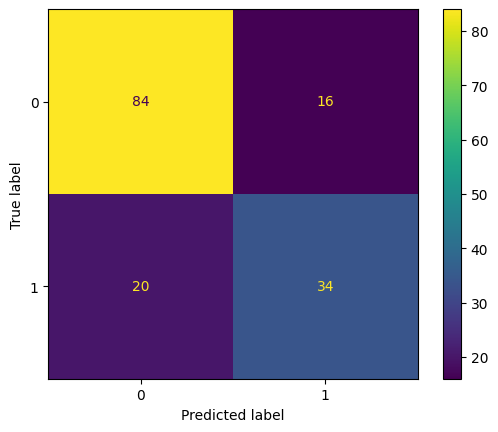

In [21]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_lgb
)

plt.show()

 XGBoost Model

In [22]:
xgb=XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train,y_train)

pred_xgb=xgb.predict(X_test)

Evaluation

In [23]:
print("Accuracy:",
      accuracy_score(y_test,pred_xgb))

print("Precision:",
      precision_score(y_test,pred_xgb))

print("Recall:",
      recall_score(y_test,pred_xgb))

print("F1 Score:",
      f1_score(y_test,pred_xgb))

Accuracy: 0.7727272727272727
Precision: 0.7021276595744681
Recall: 0.6111111111111112
F1 Score: 0.6534653465346535


Classification Report

In [24]:
print(classification_report(y_test,pred_xgb))

              precision    recall  f1-score   support

           0       0.80      0.86      0.83       100
           1       0.70      0.61      0.65        54

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154



Confusion Matrix

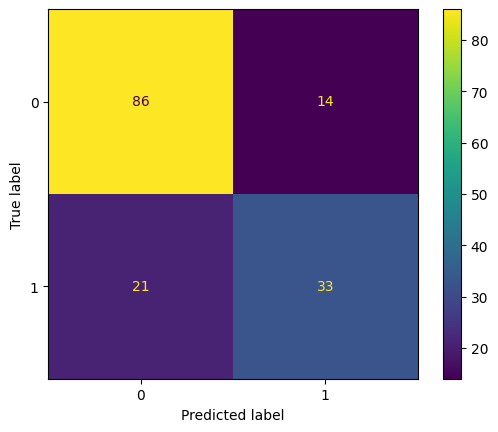

In [25]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_xgb
)

plt.show()

Cross Validation

LightGBM

In [26]:
scores=cross_val_score(
    lgbm,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(scores)
print(scores.mean())

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

XGBoost

In [27]:
scores=cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(scores)
print(scores.mean())

[0.72727273 0.71428571 0.74675325 0.78431373 0.77124183]
0.7487734487734488


Hyperparameter Tuning

LightGBM

In [28]:
params={
    "n_estimators":[100,200],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.05,0.1]
}

grid=GridSearchCV(
    lgbm,
    params,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

LightGBM

In [29]:
params={
    "n_estimators":[100,200],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.05,0.1]
}

grid=GridSearchCV(
    xgb,
    params,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
0.7590030654404905


Feature Importance

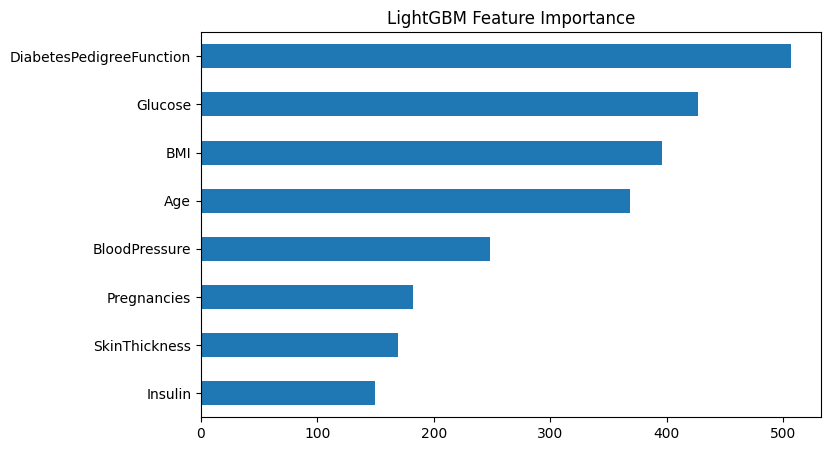

In [30]:
importance=pd.Series(
    lgbm.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("LightGBM Feature Importance")
plt.show()

XGBoost

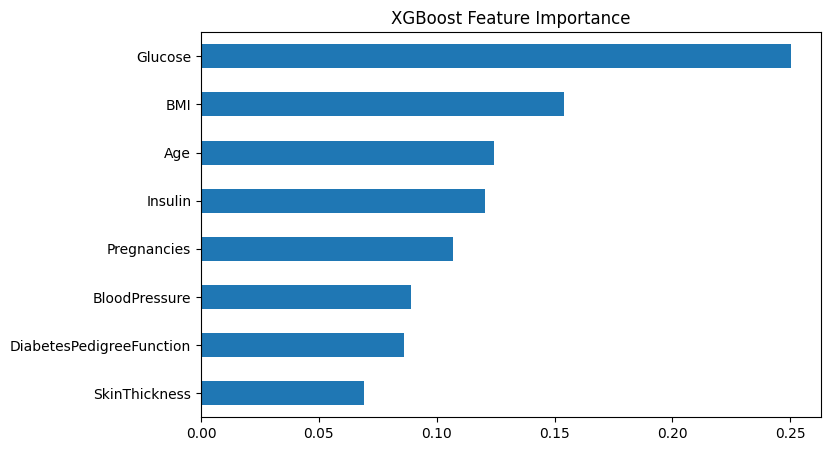

In [31]:
importance=pd.Series(
    xgb.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("XGBoost Feature Importance")
plt.show()